## Übung 9

#### Entscheidungsbäume

### Aufgabe 1: Weine Klassifizieren (10)

Sie verwenden den Ihnen schon bekannten Wein-Datensatz _wine_final.txt_. Ziel ist es anhand der Attribute die Weingüter vorherzusagen. 

__a)__ Daten verstehen 
* Verschaffen Sie sich einen geeigneten Überblick über die Daten (Visualisierung) 
* Stellen Sie mind. 3 Bedingungen auf, nach denen Sie die Daten in einem Entscheidungsbaum für die Klassifizierung separieren würden

Hinweis: Entfernen Sie den Wein, der als "unbekannt" gelabelt wurde.

Bereinigter Datensatz: 177 Weine, 13 Merkmale
Fehlende Werte: 0


,Weingut,Alcohol,Malic_acid,Ash,Alcalinity_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315,Proline
0,ArmandRousseau,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,ArmandRousseau,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,ArmandRousseau,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,ArmandRousseau,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,ArmandRousseau,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


,count,mean,std,min,25%,50%,75%,max
Alcohol,177.0,13.01,0.81,11.03,12.37,13.05,13.68,14.83
Malic_acid,177.0,2.34,1.12,0.74,1.60,1.86,3.10,5.80
Ash,177.0,2.36,0.27,1.36,2.21,2.36,2.55,3.23
Alcalinity_ash,177.0,19.44,3.28,10.60,17.20,19.50,21.50,30.00
Magnesium,177.0,99.79,14.31,70.00,88.00,98.00,107.00,162.00
Total_phenols,177.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
Flavanoids,177.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
Nonflavanoid_phenols,177.0,0.36,0.12,0.13,0.27,0.34,0.43,0.66
Proanthocyanins,177.0,1.59,0.57,0.41,1.25,1.55,1.95,3.58
Color_intensity,177.0,5.07,2.32,1.28,3.25,4.70,6.20,13.00


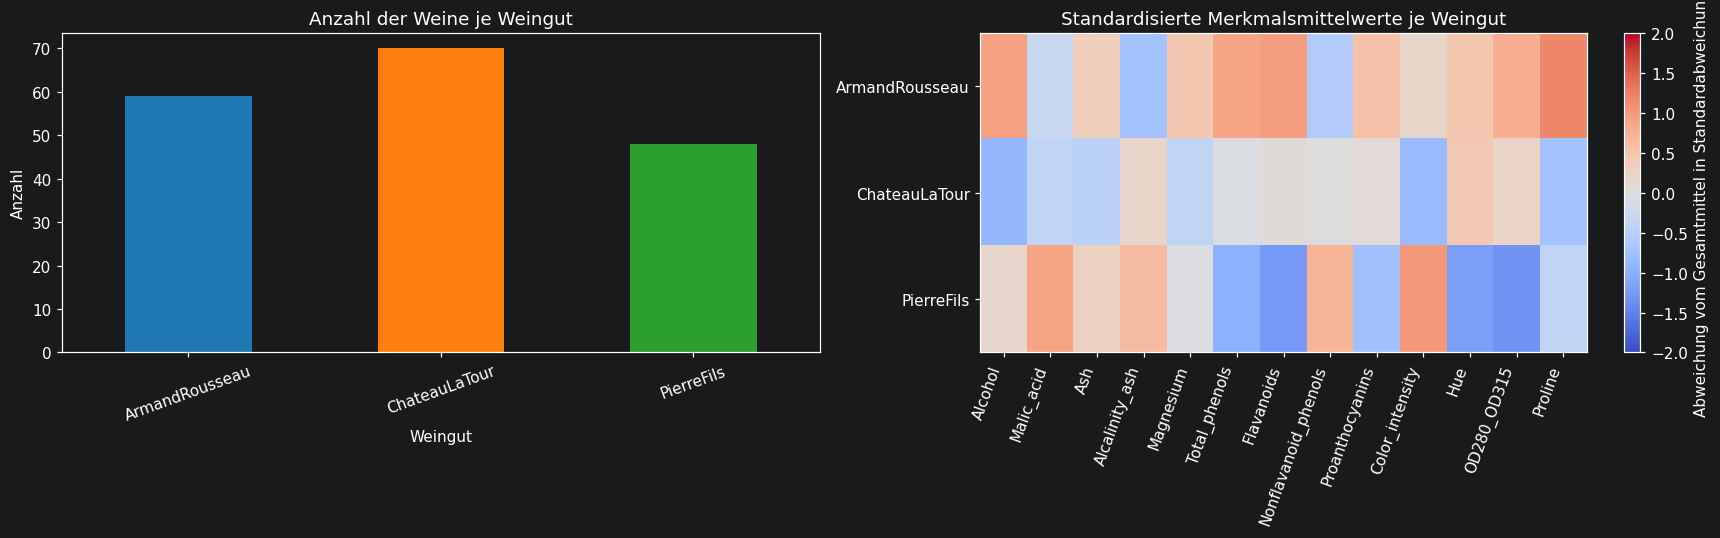

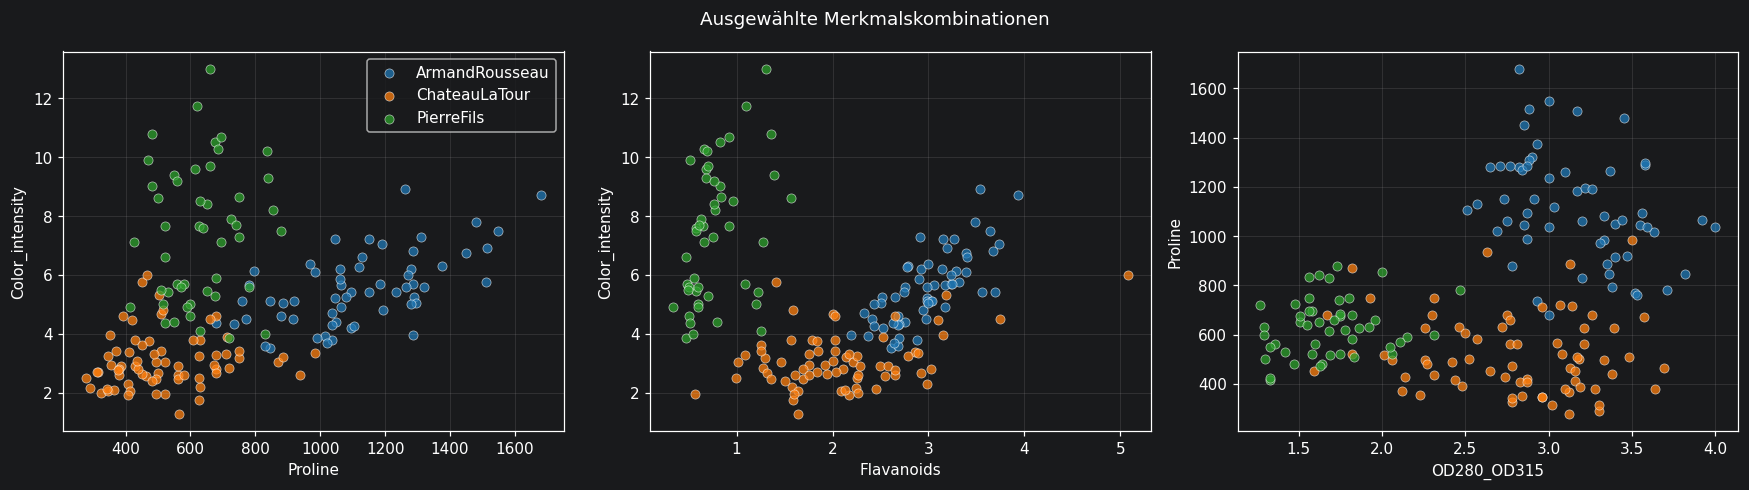

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

# Einlesen und Bereinigen der Daten
data = pd.read_csv("wine_final.txt")
data.columns = data.columns.str.strip()

data = data[data["Weingut"] != "unbekannt"].reset_index(drop=True)

feature_names = data.columns.drop("Weingut").to_list()
class_order = sorted(data["Weingut"].unique())
colors = dict(zip(class_order, ["tab:blue", "tab:orange", "tab:green"]))

print(f"Bereinigter Datensatz: {data.shape[0]} Weine, {len(feature_names)} Merkmale")
print(f"Fehlende Werte: {int(data.isna().sum().sum())}")
display(data.head())
display(data[feature_names].describe().T.round(2))

# Klassenverteilung und standardisierte Mittelwerte zum Überblick
class_counts = data["Weingut"].value_counts().reindex(class_order)
class_means = data.groupby("Weingut")[feature_names].mean().reindex(class_order)
standardized_means = (
    class_means - data[feature_names].mean()
) / data[feature_names].std()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
class_counts.plot.bar(ax=axes[0], color=[colors[label] for label in class_order])
axes[0].set_title("Anzahl der Weine je Weingut")
axes[0].set_xlabel("Weingut")
axes[0].set_ylabel("Anzahl")
axes[0].tick_params(axis="x", rotation=20)

image = axes[1].imshow(
    standardized_means,
    aspect="auto",
    cmap="coolwarm",
    vmin=-2,
    vmax=2,
)
axes[1].set_title("Standardisierte Merkmalsmittelwerte je Weingut")
axes[1].set_xticks(range(len(feature_names)), feature_names, rotation=70, ha="right")
axes[1].set_yticks(range(len(class_order)), class_order)
fig.colorbar(image, ax=axes[1], label="Abweichung vom Gesamtmittel in Standardabweichungen")
plt.tight_layout()
plt.show()

# Streudiagramme für besonders trennscharf wirkende Merkmale
feature_pairs = [
    ("Proline", "Color_intensity"),
    ("Flavanoids", "Color_intensity"),
    ("OD280_OD315", "Proline"),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (x_feature, y_feature) in zip(axes, feature_pairs):
    for label in class_order:
        subset = data[data["Weingut"] == label]
        ax.scatter(
            subset[x_feature],
            subset[y_feature],
            label=label,
            color=colors[label],
            alpha=0.75,
            edgecolor="white",
            linewidth=0.4,
        )
    ax.set_xlabel(x_feature)
    ax.set_ylabel(y_feature)
    ax.grid(alpha=0.2)
axes[0].legend()
fig.suptitle("Ausgewählte Merkmalskombinationen")
plt.tight_layout()
plt.show()

Antwort:

- `Proline > 900` spricht stark für **ArmandRousseau**.
- `Flavanoids <= 1.4` spricht stark für **PierreFils**.
- `Color_intensity < 3.5` spricht stark für **ChateauLaTour**.

Diese Bedingungen sind plausible erste Trennregeln aus den Visualisierungen. Wegen einzelner Überlappungen reichen sie allein noch nicht für jede Beobachtung aus.

__b)__ Teilen Sie die Daten in 1/3 Test und 2/3 Trainingsdaten auf. Verwenden Sie hierfür die Methode _train_test_split_. 

In [2]:
X = data.drop(columns="Weingut")
y = data["Weingut"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=1 / 3,
    random_state=1,
    stratify=y,
)

split_overview = pd.DataFrame(
    {
        "Training": y_train.value_counts(),
        "Test": y_test.value_counts(),
    }
).reindex(class_order)

print(f"Trainingsdaten: {len(X_train)} Zeilen")
print(f"Testdaten: {len(X_test)} Zeilen")
display(split_overview)

Trainingsdaten: 118 Zeilen
Testdaten: 59 Zeilen


,Training,Test
Weingut,,
ArmandRousseau,39,20
ChateauLaTour,47,23
PierreFils,32,16


'__c)__ Verwenden Sie den _DecisionTreeClassifier()_. Finden Sie heraus, wie Sie die Baumtiefe beschränken können. Erstellen Sie  3 Bäume und führen Sie alle Schritte für jeden Baum aus:
* einen kleinen Baum - stark beschränkt im Wachstum
* einen _mitteltiefen_ Baum
* einen tiefen Baum, dessen Wachstum nicht beschränkt wurde

Trainieren Sie jeden Baum auf den Trainingsdaten.


In [3]:
trees = {
    "klein": DecisionTreeClassifier(max_depth=1, random_state=42),
    "mitteltief": DecisionTreeClassifier(max_depth=3, random_state=42),
    "tief": DecisionTreeClassifier(random_state=42),
}

for model in trees.values():
    model.fit(X_train, y_train)

tree_overview = pd.DataFrame(
    {
        "max_depth gesetzt": [1, 3, None],
        "erreichte Tiefe": [model.get_depth() for model in trees.values()],
        "Blätter": [model.get_n_leaves() for model in trees.values()],
    },
    index=trees.keys(),
)
display(tree_overview)

,max_depth gesetzt,erreichte Tiefe,Blätter
klein,1.0,1,2
mitteltief,3.0,3,8
tief,NaN,4,10


Antwort: Die Baumtiefe wird mit `max_depth` begrenzt. Der kleine Baum darf nur Tiefe 1 erreichen, der mitteltiefe Baum Tiefe 3. Beim tiefen Baum bleibt `max_depth=None`; sein Wachstum wird daher nicht vorab durch die Tiefe beschränkt.

__d)__ Plotten Sie jeden Baum mit _plot_tree_

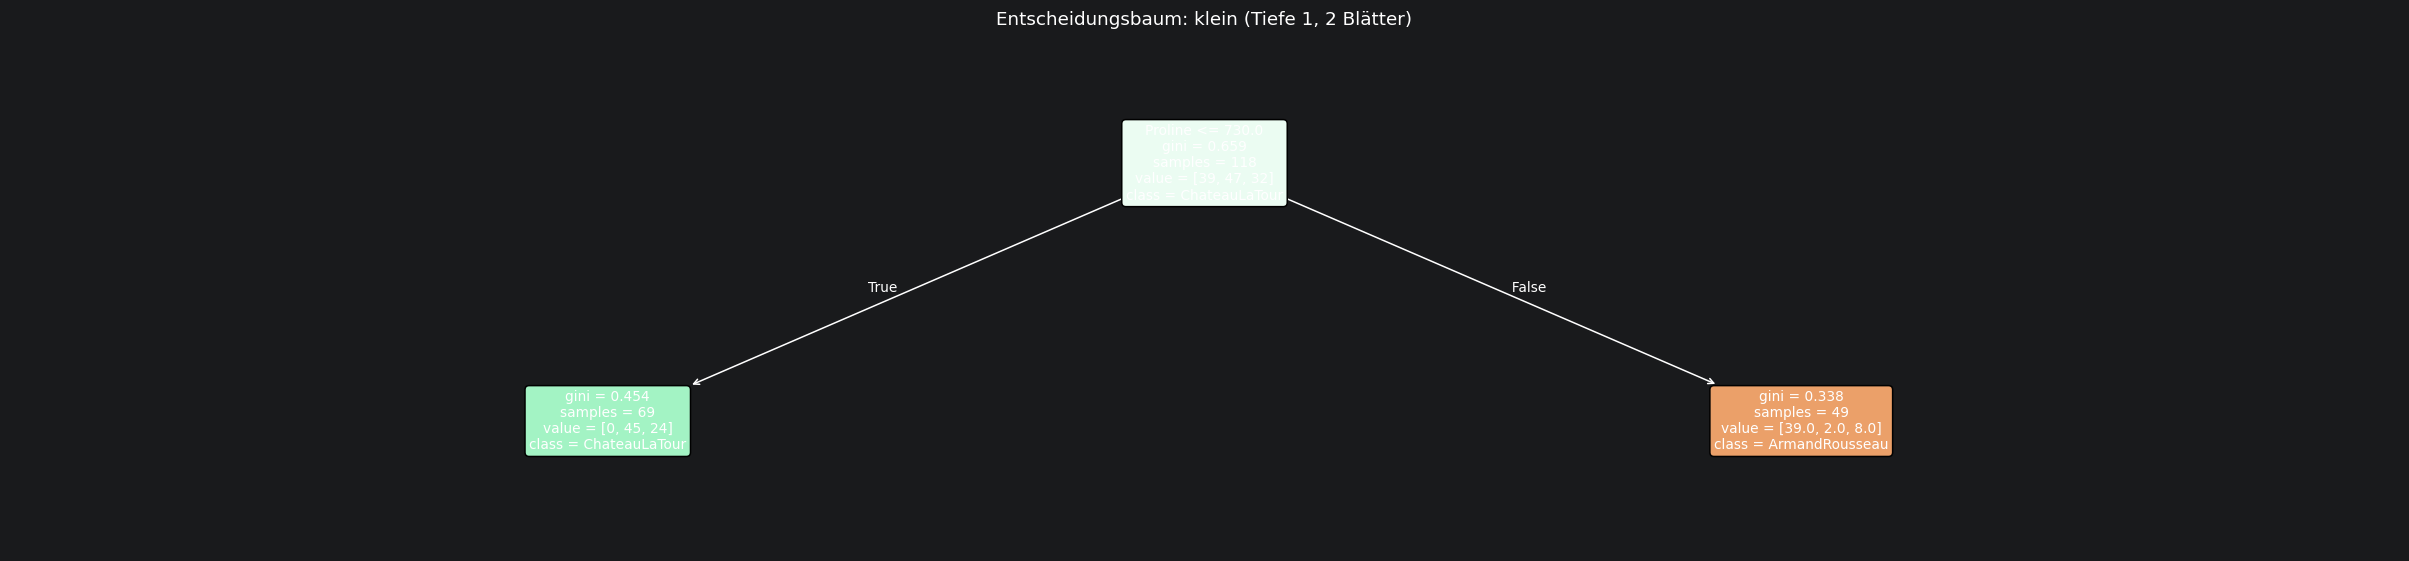

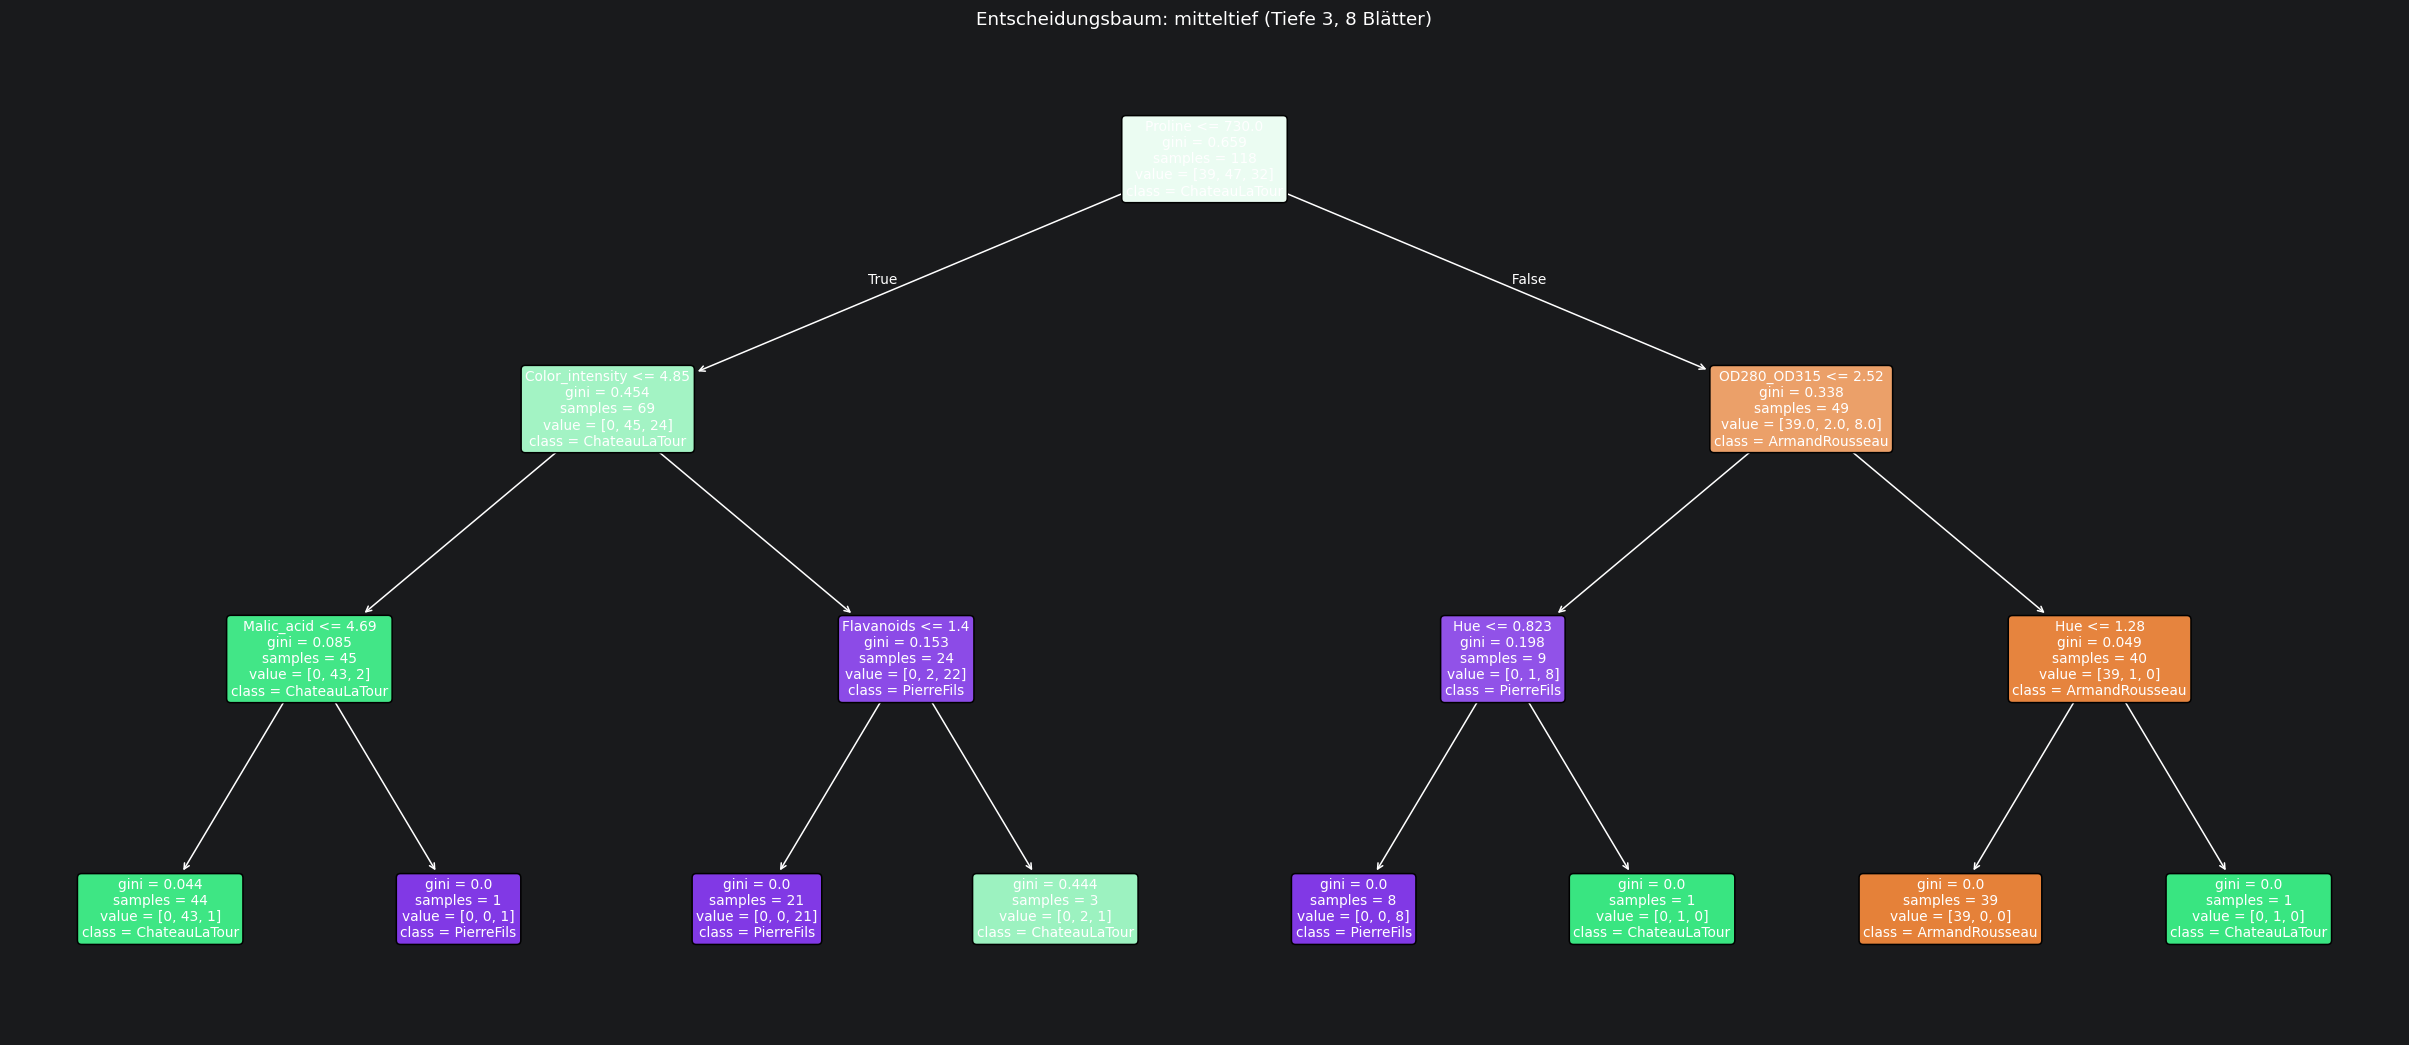

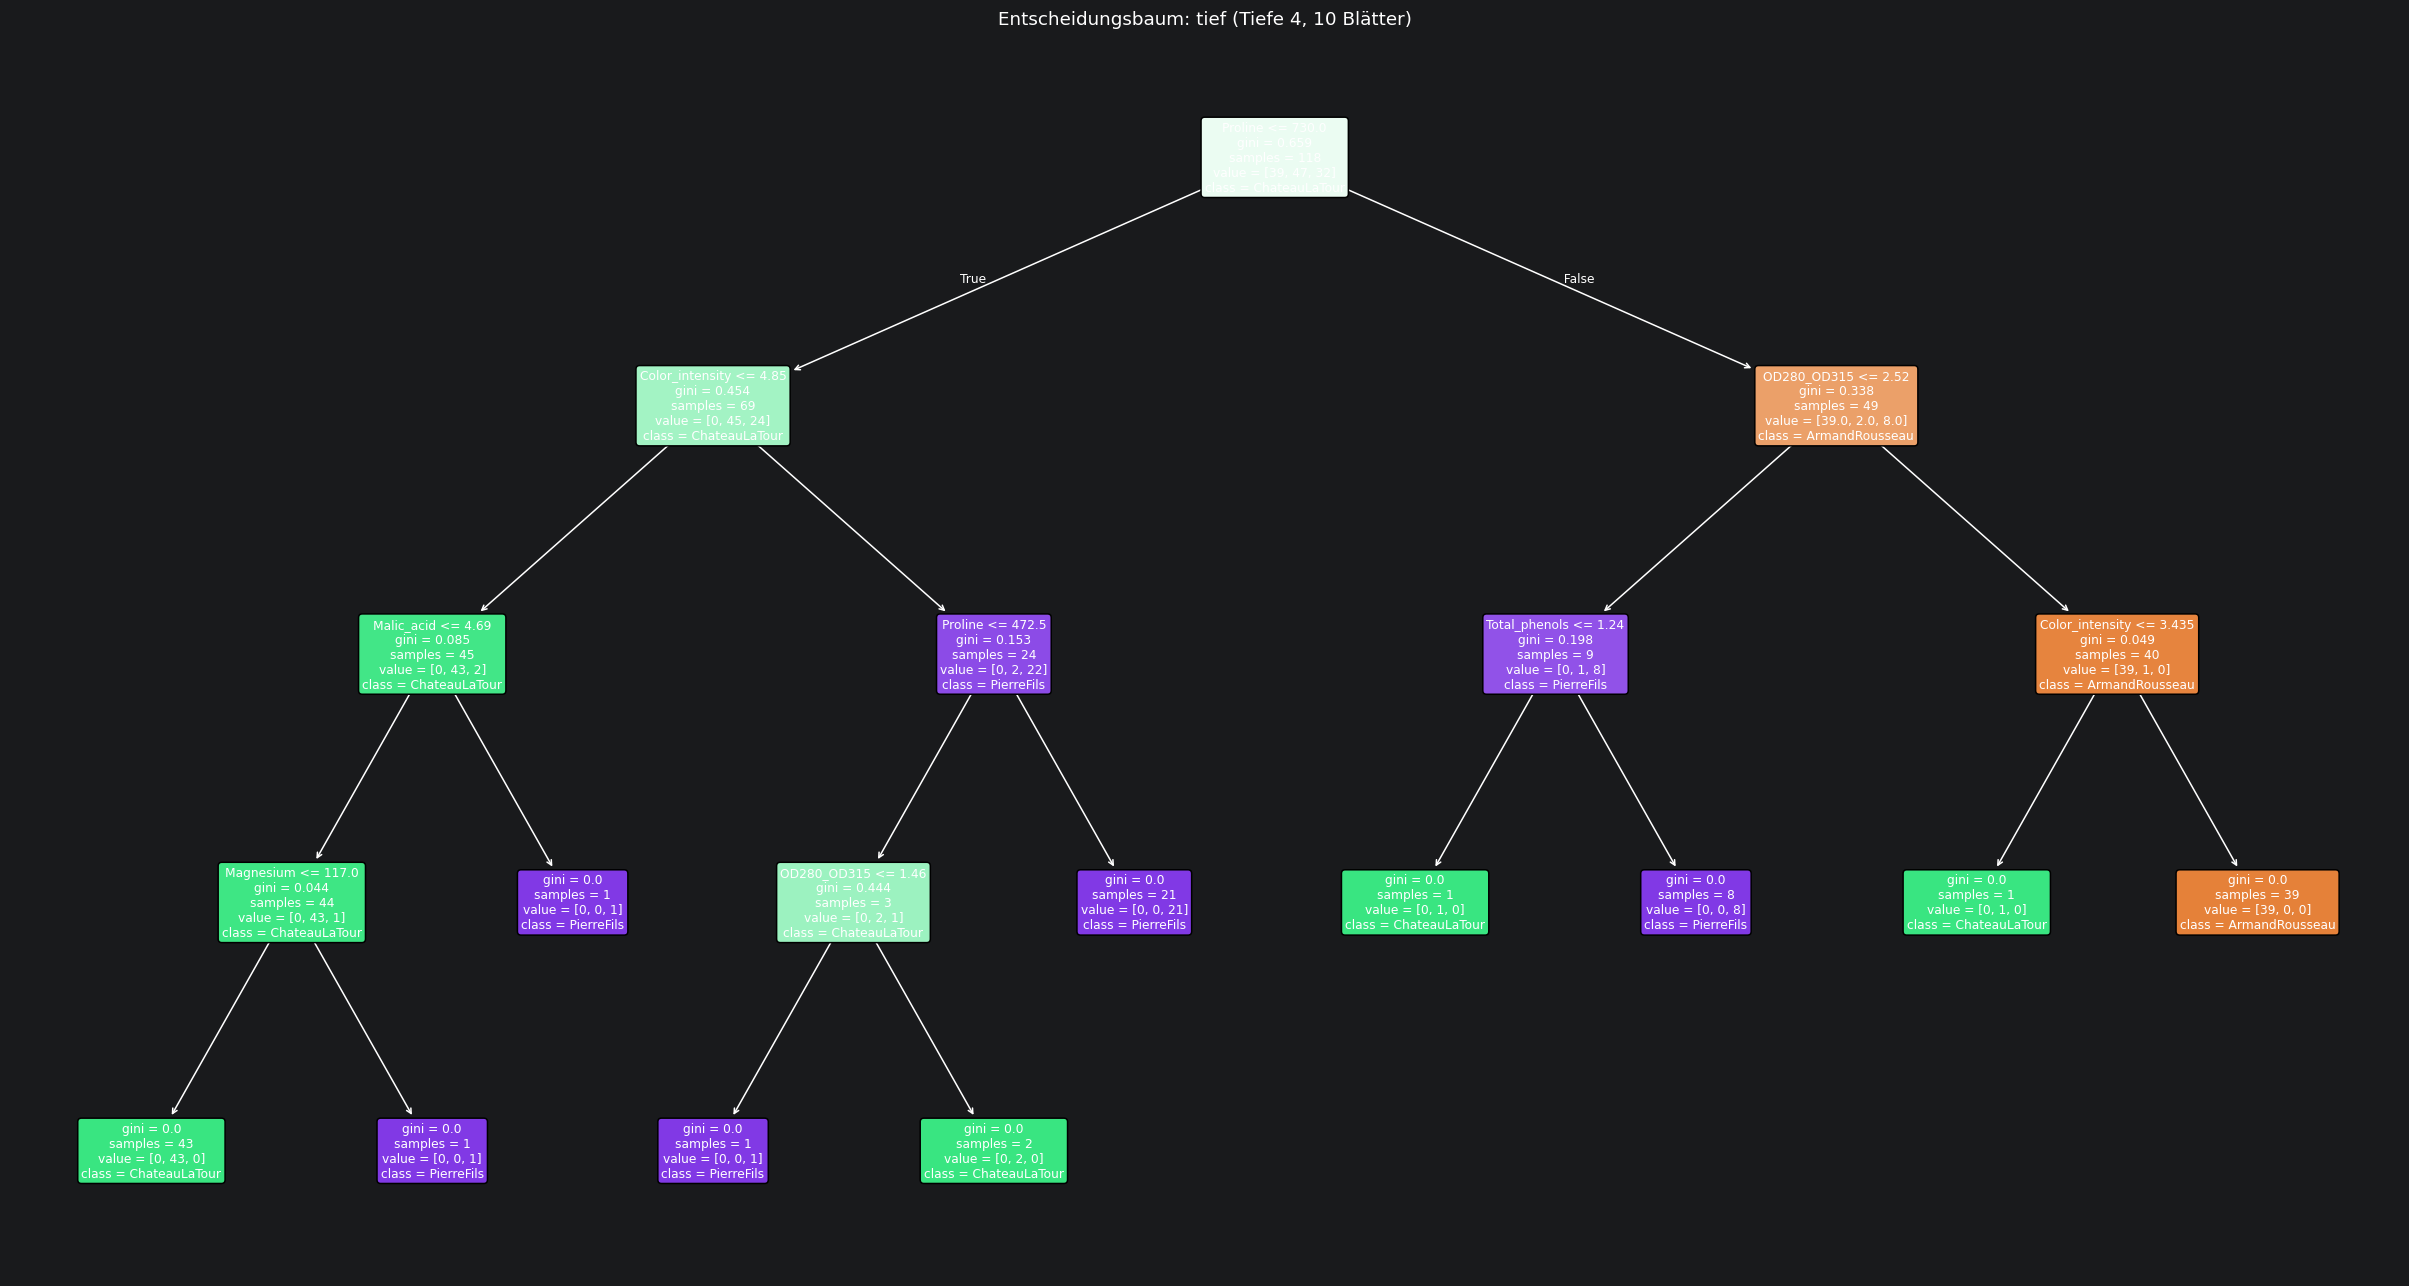

In [4]:
for name, model in trees.items():
    height = max(5, 2.2 * model.get_depth() + 3)
    fig, ax = plt.subplots(figsize=(22, height))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=class_order,
        filled=True,
        rounded=True,
        proportion=False,
        fontsize=8 if name == "tief" else 9,
        ax=ax,
    )
    ax.set_title(
        f"Entscheidungsbaum: {name} "
        f"(Tiefe {model.get_depth()}, {model.get_n_leaves()} Blätter)"
    )
    plt.tight_layout()
    plt.show()

__e)__ Verwenden sie _predict_ und lassen Sie sich für jeden Baum die Label für Trainings __und__ Testdaten vorhersagen. 

In [5]:
predictions = {}
training_predictions = pd.DataFrame(
    {"Tatsächlich": y_train.reset_index(drop=True)}
)
test_predictions = pd.DataFrame(
    {"Tatsächlich": y_test.reset_index(drop=True)}
)

for name, model in trees.items():
    predictions[name] = {
        "Training": model.predict(X_train),
        "Test": model.predict(X_test),
    }
    training_predictions[name] = predictions[name]["Training"]
    test_predictions[name] = predictions[name]["Test"]

print("Vorhersagen für die Trainingsdaten:")
display(training_predictions)
print("Vorhersagen für die Testdaten:")
display(test_predictions)

Vorhersagen für die Trainingsdaten:


,Tatsächlich,klein,mitteltief,tief
0,ArmandRousseau,ArmandRousseau,ArmandRousseau,ArmandRousseau
1,ChateauLaTour,ChateauLaTour,ChateauLaTour,ChateauLaTour
2,PierreFils,ChateauLaTour,PierreFils,PierreFils
3,PierreFils,ChateauLaTour,PierreFils,PierreFils
4,ArmandRousseau,ArmandRousseau,ArmandRousseau,ArmandRousseau
...,...,...,...,...
113,ChateauLaTour,ChateauLaTour,ChateauLaTour,ChateauLaTour
114,ChateauLaTour,ChateauLaTour,ChateauLaTour,ChateauLaTour
115,ArmandRousseau,ArmandRousseau,ArmandRousseau,ArmandRousseau
116,ChateauLaTour,ChateauLaTour,ChateauLaTour,ChateauLaTour


Vorhersagen für die Testdaten:


,Tatsächlich,klein,mitteltief,tief
0,PierreFils,ChateauLaTour,PierreFils,ChateauLaTour
1,ChateauLaTour,ArmandRousseau,ArmandRousseau,ChateauLaTour
2,ChateauLaTour,ChateauLaTour,ChateauLaTour,ChateauLaTour
3,ChateauLaTour,ChateauLaTour,ChateauLaTour,ChateauLaTour
4,ChateauLaTour,ChateauLaTour,ChateauLaTour,ChateauLaTour
5,ArmandRousseau,ArmandRousseau,ArmandRousseau,ArmandRousseau
6,ChateauLaTour,ChateauLaTour,ChateauLaTour,PierreFils
7,ChateauLaTour,ChateauLaTour,PierreFils,PierreFils
8,ChateauLaTour,ChateauLaTour,ChateauLaTour,ChateauLaTour
9,ArmandRousseau,ArmandRousseau,ArmandRousseau,ArmandRousseau


__f)__ Berechnen Sie mit scikit-learn die Confusionmatrix und gängige Metriken wie Accuracy, MCC, Macro-Sensitivity und Macro-F1-Score. 

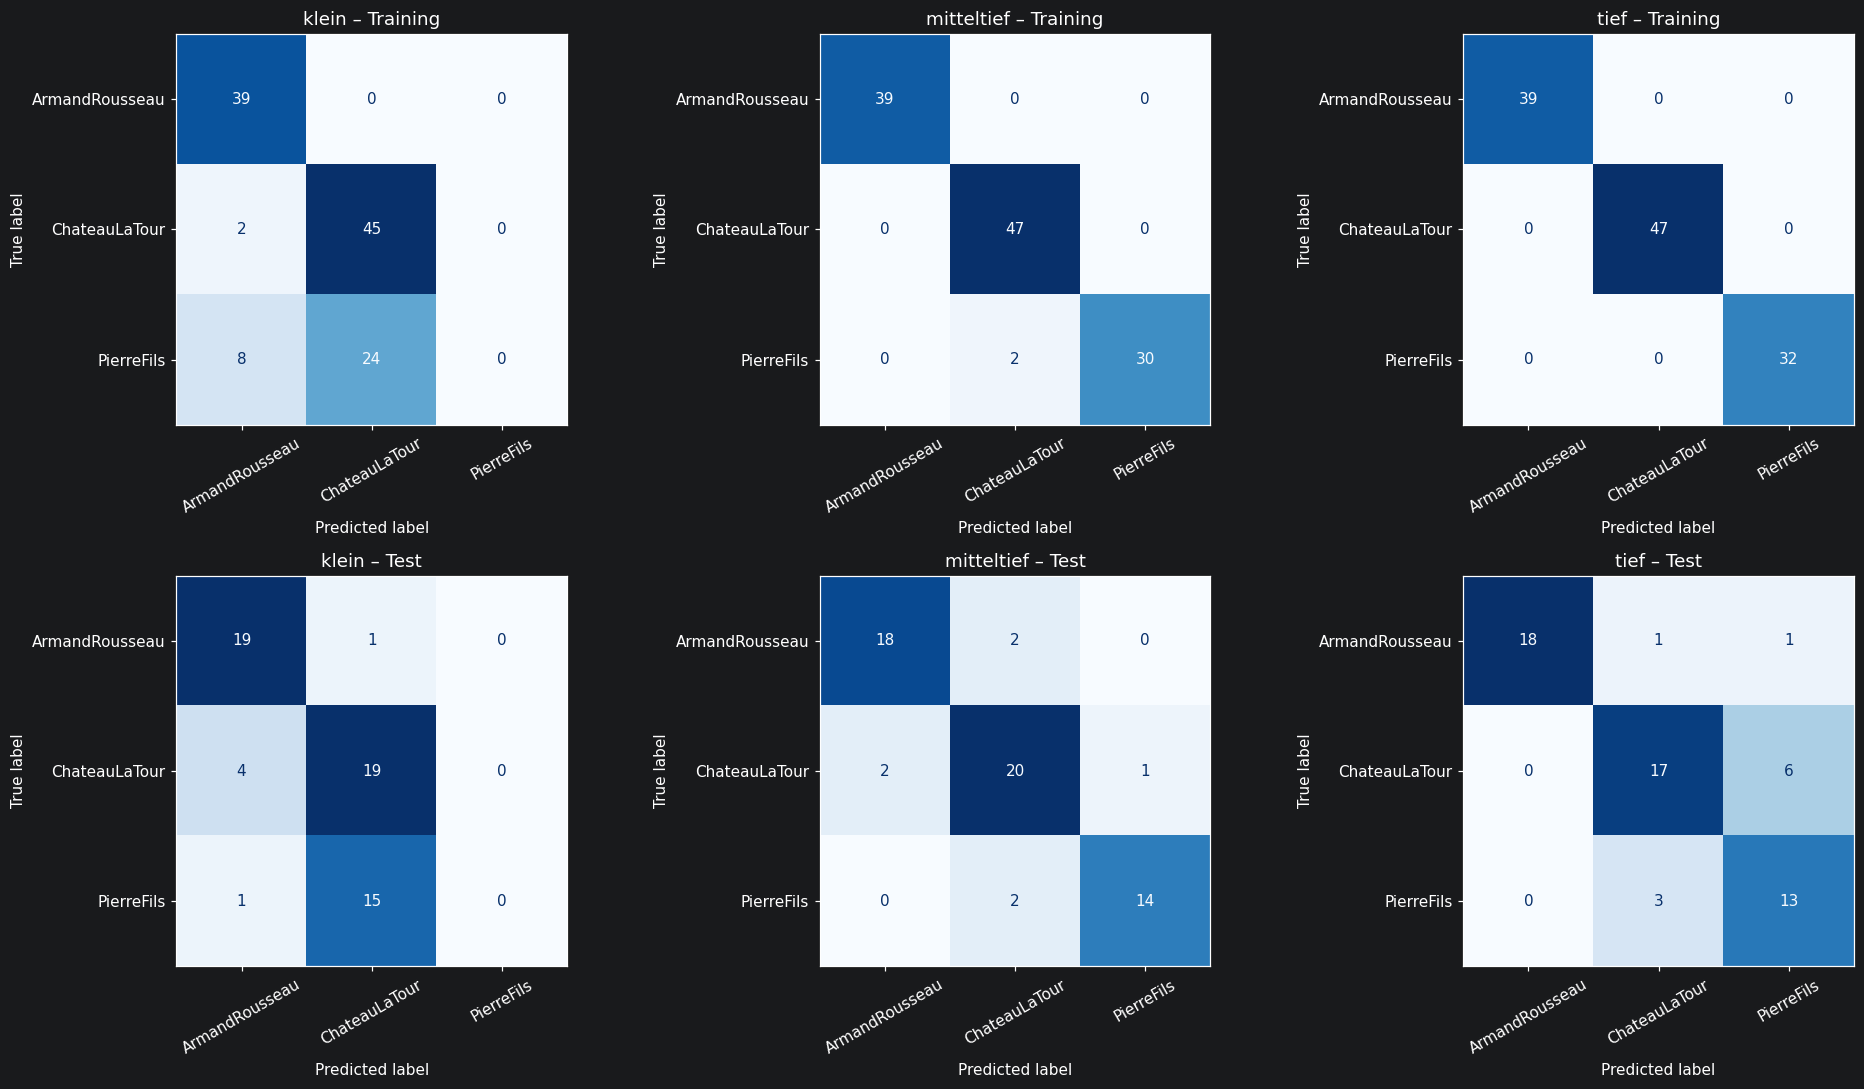

,Baum,Datensatz,Accuracy,MCC,Macro-Sensitivität,Macro-F1
0,klein,Training,0.712,0.604,0.652,0.554
1,klein,Test,0.644,0.487,0.592,0.506
2,mitteltief,Training,0.983,0.975,0.979,0.982
3,mitteltief,Test,0.881,0.820,0.882,0.885
4,tief,Training,1.000,1.000,1.000,1.000
5,tief,Test,0.814,0.724,0.817,0.814


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_records = []

for column, (name, model) in enumerate(trees.items()):
    for row, (dataset_name, y_true) in enumerate(
        [("Training", y_train),
         ("Test", y_test)]
    ):
        y_pred = predictions[name][dataset_name]
        ConfusionMatrixDisplay.from_predictions(
            y_true,
            y_pred,
            labels=class_order,
            display_labels=class_order,
            cmap="Blues",
            colorbar=False,
            ax=axes[row, column],
        )
        axes[row, column].set_title(f"{name} – {dataset_name}")
        axes[row, column].tick_params(axis="x", rotation=30)

        metrics_records.append(
            {
                "Baum": name,
                "Datensatz": dataset_name,
                "Accuracy": accuracy_score(y_true, y_pred),
                "MCC": matthews_corrcoef(y_true, y_pred),
                "Macro-Sensitivität": recall_score(
                    y_true, y_pred, average="macro", zero_division=0
                ),
                "Macro-F1": f1_score(
                    y_true, y_pred, average="macro", zero_division=0
                ),
            }
        )

plt.tight_layout()
plt.show()

metrics_table = pd.DataFrame(metrics_records)
display(metrics_table.round(3))

__g)__ Stellen Sie die Kenngrößen in einer Tabelle einander vergleichend gegenüber.
Warum macht es Sinn, sich auch die Performance auf den Trainingsdaten anzuschauen?


In [7]:
comparison = (
    metrics_table
    .set_index(["Baum", "Datensatz"])
    .sort_index()
)
display(comparison.round(3))

Accuracy    MCC  Macro-Sensitivität  Macro-F1
Baum       Datensatz                                               
klein      Test          0.644  0.487               0.592     0.506
           Training      0.712  0.604               0.652     0.554
mitteltief Test          0.881  0.820               0.882     0.885
           Training      0.983  0.975               0.979     0.982
tief       Test          0.814  0.724               0.817     0.814
           Training      1.000  1.000               1.000     1.000

Antwort: Die Trainingsperformance zeigt, ob ein Modell die Trainingsdaten nur unzureichend lernt oder sie zu stark auswendig lernt. Der kleine Baum ist bereits im Training schwach und hat daher Underfitting. Der tiefe Baum erreicht im Training perfekte Werte, verliert im Test aber deutlich; diese Lücke ist ein Hinweis auf Overfitting. Der mitteltiefe Baum liefert hier den besseren Kompromiss.

### Aufgabe 2: Bäume verstehen (15)

Basierend auf Aufgabe 1

__a)__ Vergleichen Sie Ihre aufgestellten Bediungungen mit denen des Entscheidungsbaumes. Lassen Sie sich hierfür auch für jeden Baum die Feature-importance `feature_importances_`anzeigen.

,klein,mitteltief,tief
Proline,1.0,0.401,0.414
Color_intensity,0.0,0.320,0.332
OD280_OD315,0.0,0.173,0.182
Magnesium,0.0,0.000,0.025
Malic_acid,0.0,0.025,0.024
Total_phenols,0.0,0.000,0.023
Alcalinity_ash,0.0,0.000,0.000
Alcohol,0.0,0.000,0.000
Ash,0.0,0.000,0.000
Proanthocyanins,0.0,0.000,0.000


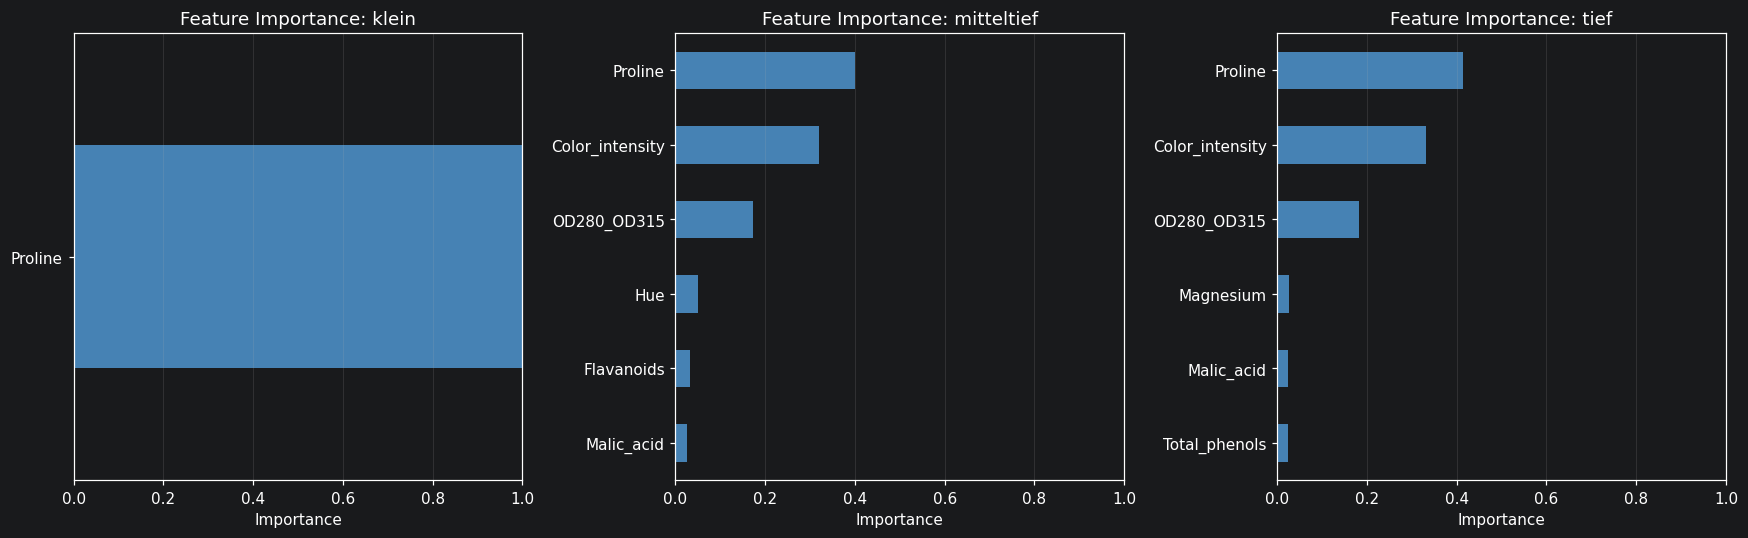

In [9]:

data = {}

for name, model in trees.items():
    data[name] = model.feature_importances_
importance_df = pd.DataFrame(data, index=feature_names)

display(importance_df.sort_values("tief", ascending=False).round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, trees):
    nonzero = importance_df[name][importance_df[name] > 0].sort_values()
    nonzero.plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"Feature Importance: {name}")
    ax.set_xlabel("Importance")
    ax.set_xlim(0, 1)
    ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

Antwort: Die selbst aufgestellten Bedingungen passen gut zum gelernten Baum. Der Baum verwendet `Proline`, `Color_intensity` und teilweise `Flavanoids`; nur die genauen Schwellenwerte werden datengetrieben angepasst. Beim kleinen Baum ist `Proline` das einzige Merkmal. Bei den größeren Bäumen haben `Proline` und `Color_intensity` die größte Bedeutung.

__b)__ Wie ist die Featureimportance für Entscheidungsbäume definiert (für Gini oder Entropie)?

Antwort: Die Feature Importance eines Entscheidungsbaums basiert darauf, wie stark ein Attribut die Unreinheit der Daten reduziert.

Der Informationsgewinn bzw. die Unreinheitsreduktion ist definiert als:

$$
G(D, A) = I(D) - \sum_{i=1}^{n} \frac{|D_i|}{|D|} \cdot I(D_i)
$$

- $D$: ursprüngliche Datenmenge

- $A$: betrachtetes Attribut / Feature

- $D_i$: Teilmenge nach dem Split

- $\frac{|D_i|}{|D|}$: Anteil der Teilmenge an der Gesamtmenge

- $I(D)$: Unreinheit der ursprünglichen Datenmenge

- $I(D_i)$: Unreinheit der jeweiligen Teilmenge

Für $I(D)$ kann zum Beispiel die **Gini-Unreinheit** oder die **Entropie** verwendet werden.

**Gini-Unreinheit:**

$$
I_{\mathrm{Gini}}(D) = 1 - \sum_{k=1}^{K} p_k^2
$$

- $K$: Anzahl der Klassen

- $p_k$: Anteil der Klasse $k$ in der Datenmenge $D$

- $p_k^2$: quadrierter Klassenanteil

Die Gini-Unreinheit ist $0$, wenn alle Datenpunkte in $D$ zur gleichen Klasse gehören. Je größer der Wert ist, desto stärker sind die Klassen gemischt.

**Entropie:**

$$
I_{\mathrm{Entropie}}(D) = - \sum_{k=1}^{K} p_k \log_2(p_k)
$$

- $K$: Anzahl der Klassen

- $p_k$: Anteil der Klasse $k$

- $\log_2(p_k)$: Logarithmus zur Basis 2

- $p_k \log_2(p_k)$: gewichteter Informationsanteil der Klasse

Die Entropie ist ebenfalls $0$, wenn alle Datenpunkte in $D$ zur gleichen Klasse gehören. Je größer die Entropie ist, desto größer ist die Unsicherheit bzw. Durchmischung der Klassen.

Ein Feature ist umso wichtiger, je stärker es über alle Splits hinweg die Unreinheit reduziert. Die Feature Importance eines Features ergibt sich also aus der Summe aller Unreinheitsreduktionen, bei denen dieses Feature für einen Split verwendet wurde.

__c)__ Baumtiefen einschätzen 

Basierend auf unterschiedlich tiefen Entscheidungsbäumen, erstellen Sie ein Diagramm mit der Performance (z.B. MCC) je Baum in Abhängigkeit von seiner Blattanzahl - erstellen Sie dafür mehr als 3 Bäume. Visualisieren Sie dabei beides, die Trainings- und die Testperformance.

,Blätter,MCC Training,MCC Test
0,2,0.604,0.487
1,3,0.827,0.746
2,4,0.923,0.770
3,5,0.936,0.718
4,6,0.949,0.718
5,7,0.961,0.718
6,8,0.974,0.670
7,9,0.987,0.694
8,10,1.000,0.694


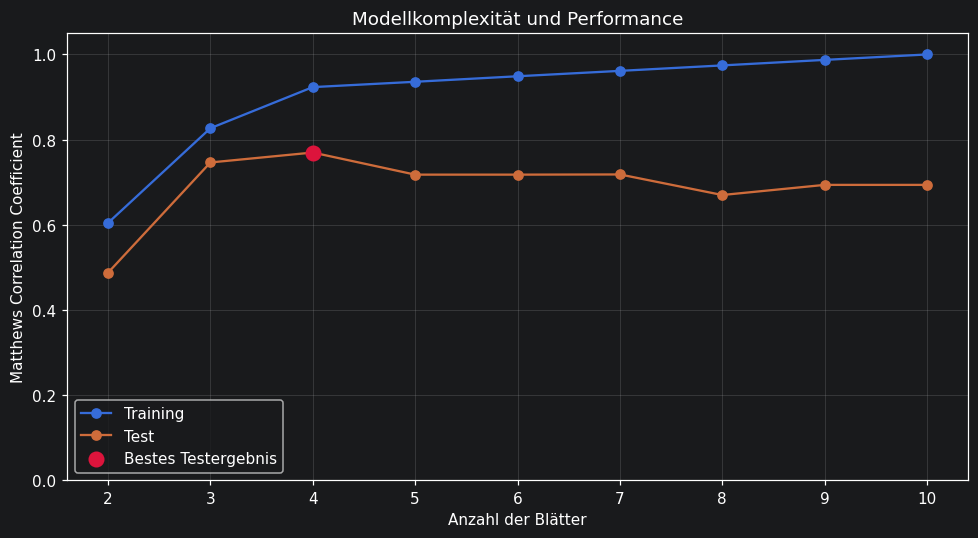

In [10]:
leaf_records = []

for max_leaves in range(2, 11):
    model = DecisionTreeClassifier(
        max_leaf_nodes=max_leaves,
        random_state=42,
    )
    model.fit(X_train, y_train)
    leaf_records.append(
        {
            "Blätter": model.get_n_leaves(),
            "MCC Training": matthews_corrcoef(
                y_train, model.predict(X_train)
            ),
            "MCC Test": matthews_corrcoef(
                y_test, model.predict(X_test)
            ),
        }
    )

leaf_curve = pd.DataFrame(leaf_records)
display(leaf_curve.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    leaf_curve["Blätter"],
    leaf_curve["MCC Training"],
    marker="o",
    label="Training",
)
ax.plot(
    leaf_curve["Blätter"],
    leaf_curve["MCC Test"],
    marker="o",
    label="Test",
)
best_test = leaf_curve.loc[leaf_curve["MCC Test"].idxmax()]
ax.scatter(
    best_test["Blätter"],
    best_test["MCC Test"],
    color="crimson",
    s=90,
    zorder=3,
    label="Bestes Testergebnis",
)
ax.set_xlabel("Anzahl der Blätter")
ax.set_ylabel("Matthews Correlation Coefficient")
ax.set_title("Modellkomplexität und Performance")
ax.set_xticks(leaf_curve["Blätter"])
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

Antwort: Mit zusätzlichen Blättern steigt die MCC im Training bis auf 1. Die Test-MCC erreicht ihr Maximum bereits bei vier Blättern und sinkt danach wieder. Wenige Blätter führen hier zu Underfitting; zu viele Blätter erhöhen die Anpassung an Besonderheiten der Trainingsdaten.

__e)__ Verwenden Sie die zwei wichtigsten Merkmale und Visualisieren Sie hier die Decision Surfaces für einen Baum mit under- bzw. over fitting (wandeln Sie hierfür z.B. den Code für die Decision Surfaces aus https://data-science-crashkurs.de/chapters/kapitel_07.html#decision-surfaces entsprechend ab).

Die zwei wichtigsten Merkmale: ['Proline', 'Color_intensity']


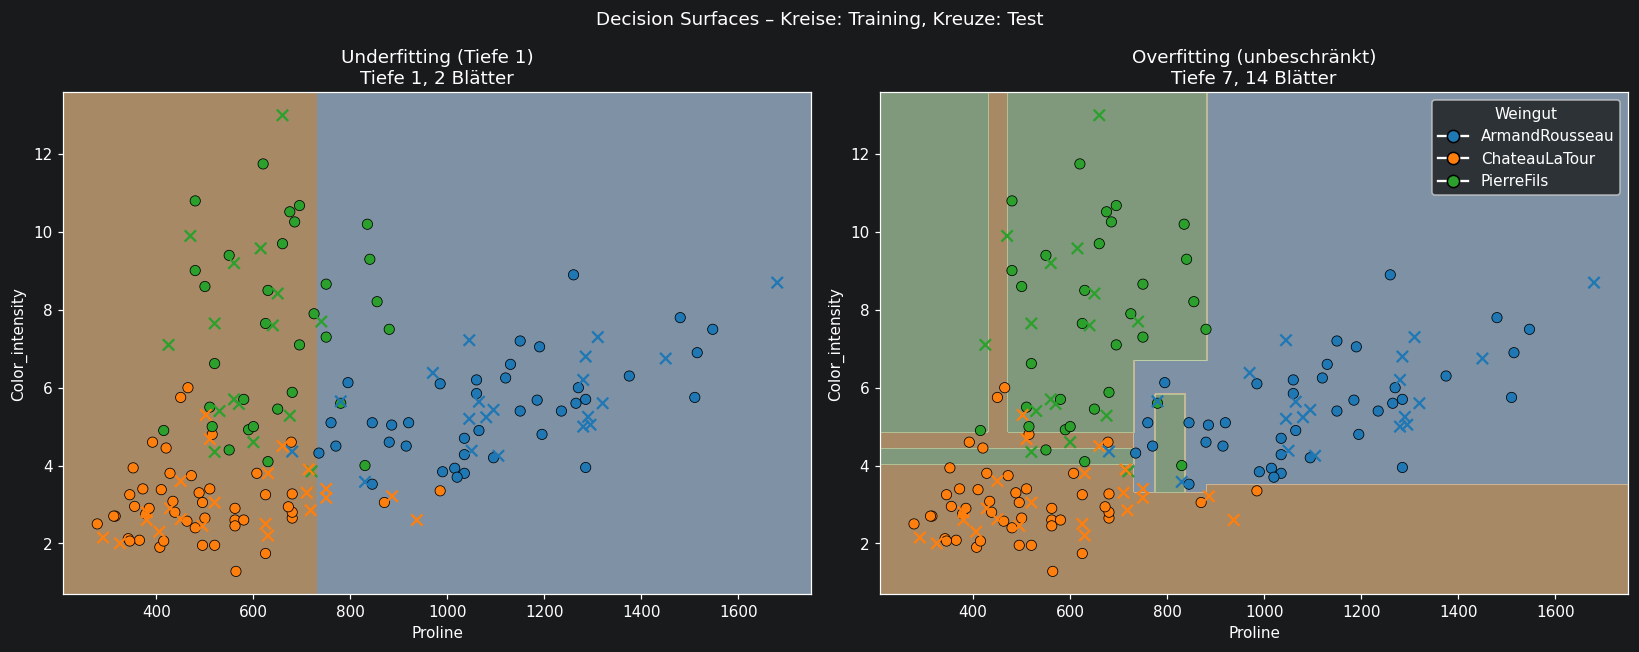

,MCC Training,MCC Test
Modell,,
Underfitting (Tiefe 1),0.604,0.487
Overfitting (unbeschränkt),1.000,0.796


In [11]:
top_features = importance_df["tief"].nlargest(2).index.to_list()
print(f"Die zwei wichtigsten Merkmale: {top_features}")

label_encoder = LabelEncoder()
label_encoder.fit(y)
y_train_numeric = label_encoder.transform(y_train)
y_test_numeric = label_encoder.transform(y_test)

X_train_surface = X_train[top_features]
X_test_surface = X_test[top_features]

surface_trees = {
    "Underfitting (Tiefe 1)": DecisionTreeClassifier(
        max_depth=1, random_state=42
    ),
    "Overfitting (unbeschränkt)": DecisionTreeClassifier(
        random_state=42
    ),
}
for model in surface_trees.values():
    model.fit(X_train_surface, y_train_numeric)

x_margin = 0.05 * (
    X[top_features[0]].max() - X[top_features[0]].min()
)
y_margin = 0.05 * (
    X[top_features[1]].max() - X[top_features[1]].min()
)
x_values = np.linspace(
    X[top_features[0]].min() - x_margin,
    X[top_features[0]].max() + x_margin,
    350,
)
y_values = np.linspace(
    X[top_features[1]].min() - y_margin,
    X[top_features[1]].max() + y_margin,
    350,
)
xx, yy = np.meshgrid(x_values, y_values)
grid = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=top_features,
)

surface_cmap = ListedColormap(["#b7d4f0", "#f5c58f", "#b8dfb0"])
point_cmap = ListedColormap(["tab:blue", "tab:orange", "tab:green"])
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
surface_metrics = []

for ax, (name, model) in zip(axes, surface_trees.items()):
    surface = model.predict(grid).reshape(xx.shape)
    ax.contourf(
        xx,
        yy,
        surface,
        alpha=0.65,
        cmap=surface_cmap,
        levels=np.arange(len(class_order) + 1) - 0.5,
    )
    ax.scatter(
        X_train_surface[top_features[0]],
        X_train_surface[top_features[1]],
        c=y_train_numeric,
        cmap=point_cmap,
        edgecolors="black",
        linewidths=0.5,
        s=45,
    )
    ax.scatter(
        X_test_surface[top_features[0]],
        X_test_surface[top_features[1]],
        c=y_test_numeric,
        cmap=point_cmap,
        marker="x",
        linewidths=1.5,
        s=55,
    )
    ax.set_xlabel(top_features[0])
    ax.set_ylabel(top_features[1])
    ax.set_title(
        f"{name}\nTiefe {model.get_depth()}, "
        f"{model.get_n_leaves()} Blätter"
    )

    surface_metrics.append(
        {
            "Modell": name,
            "MCC Training": matthews_corrcoef(
                y_train_numeric, model.predict(X_train_surface)
            ),
            "MCC Test": matthews_corrcoef(
                y_test_numeric, model.predict(X_test_surface)
            ),
        }
    )

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="white",
        markerfacecolor=point_cmap.colors[index],
        markeredgecolor="black",
        label=label,
        markersize=8,
    )
    for index, label in enumerate(label_encoder.classes_)
]
axes[1].legend(handles=legend_handles, title="Weingut", loc="best")
fig.suptitle("Decision Surfaces – Kreise: Training, Kreuze: Test")
plt.tight_layout()
plt.show()

display(pd.DataFrame(surface_metrics).set_index("Modell").round(3))

Antwort: Die Underfitting-Surface besteht nur aus zwei großen Bereichen und kann die drei Klassen nicht angemessen trennen. Die unbeschränkte Surface bildet deutlich mehr rechteckige Teilbereiche. Sie passt sich dadurch stärker an einzelne Trainingspunkte an und reagiert empfindlicher auf die konkrete Stichprobe.

__f)__ Diskutieren Sie wieder den Bias-Variance Tradeoff an diesem Beispiel. Wo ist viel Bias, wo viel Variance? Wie sieht es mit over und underfitting aus?

Antwort:

- Der stark beschränkte Baum hat hohen Bias und niedrige Varianz. Seine Regeln sind zu einfach, deshalb sind Trainings- und Testleistung niedrig: Underfitting.
- Der unbeschränkte Baum hat niedrigen Bias und höhere Varianz. Er erreicht perfekte Trainingswerte, reagiert aber stärker auf die konkrete Trainingsstichprobe: Overfitting.
- Der mitteltiefe Baum liegt zwischen beiden Extremen. Er bildet die Struktur der Daten ausreichend genau ab, ohne jede Besonderheit der Trainingsdaten zu übernehmen.

#### Zusatzaufgabe: Featureimportance berechnen (10)

__a)__ Verwenden Sie Ihren kleinen Baum von oben, oder erstellen Sie einen neuen kleinen Baum. Der Baum soll 2 bis 3 Entscheidungen treffen. Verwenden Sie als `criterion` _gini_ (Standard) oder _entropy_. Visualisieren Sie ihn mit `plot_tree()`


Tiefe: 2, Blätter: 4, Entscheidungen: 3


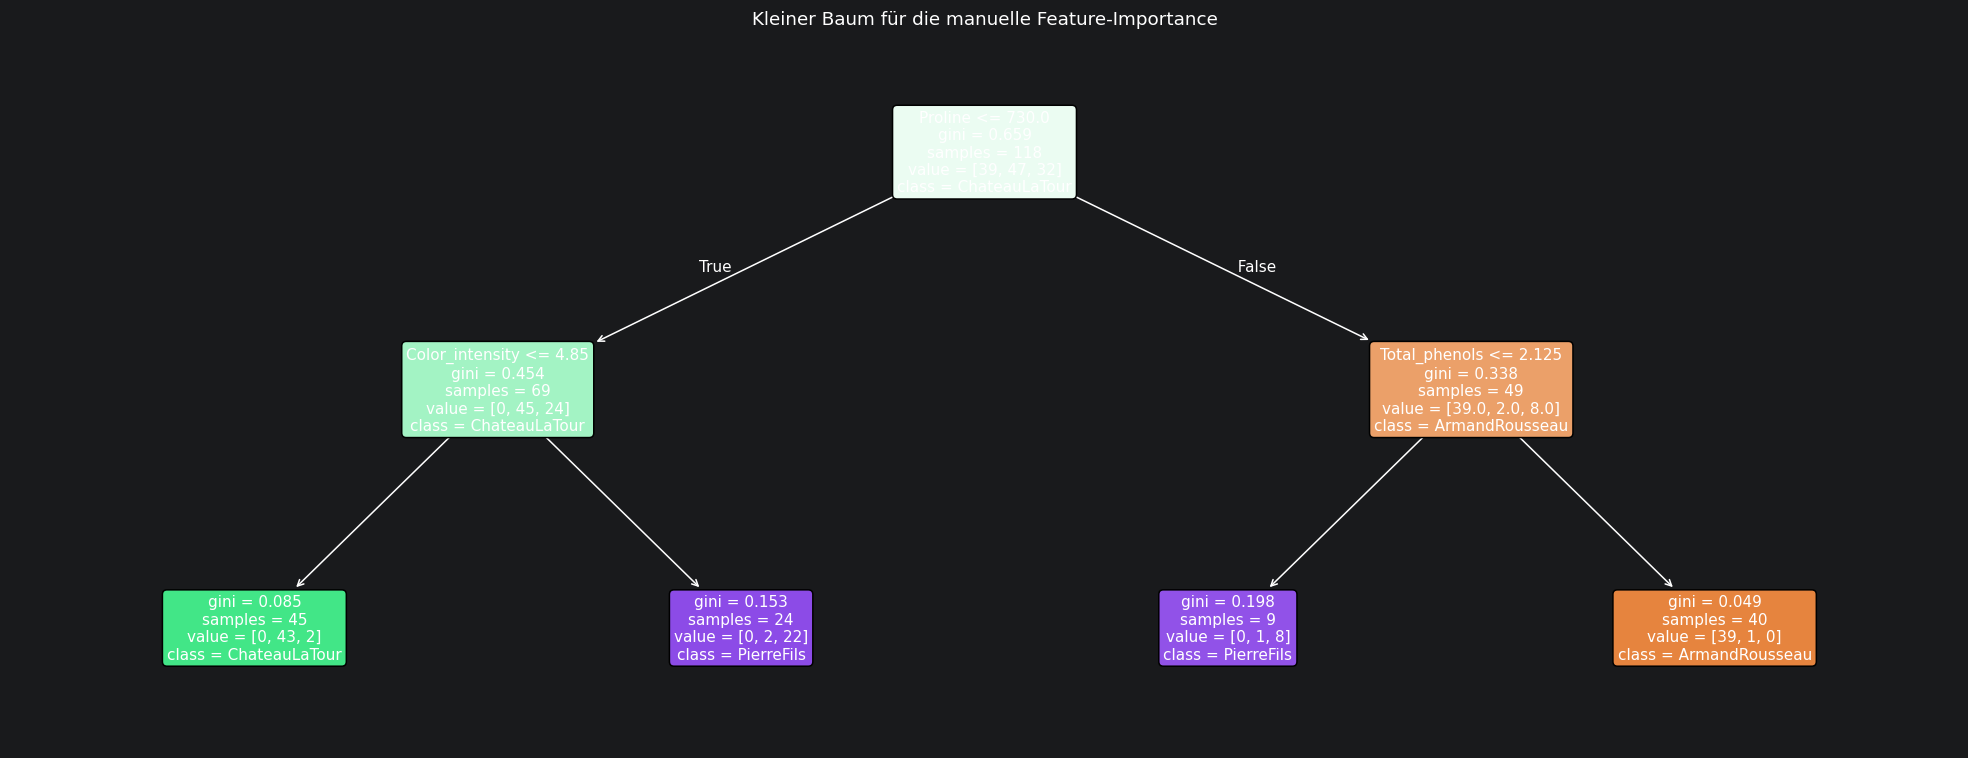

In [12]:
manual_tree = DecisionTreeClassifier(
    criterion="gini",
    max_leaf_nodes=4,
    random_state=42,
)
manual_tree.fit(X_train, y_train)

decision_count = int(
    np.sum(manual_tree.tree_.children_left != -1)
)
print(
    f"Tiefe: {manual_tree.get_depth()}, "
    f"Blätter: {manual_tree.get_n_leaves()}, "
    f"Entscheidungen: {decision_count}"
)

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    manual_tree,
    feature_names=feature_names,
    class_names=class_order,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
)
ax.set_title("Kleiner Baum für die manuelle Feature-Importance")
plt.tight_layout()
plt.show()

__b)__ Lassen Sie sich die Feature importance ausgeben

In [13]:
manual_tree_importance = pd.Series(
    manual_tree.feature_importances_,
    index=feature_names,
    name="Feature Importance",
)
display(
    manual_tree_importance[manual_tree_importance > 0]
    .sort_values(ascending=False)
    .to_frame()
    .round(4)
)

,Feature Importance
Proline,0.4487
Color_intensity,0.3582
Total_phenols,0.1932


__c)__ Berechnen Sie die Featureimportance von Hand und überprüfen Sie, ob Ihre Ergebnissen mit denen von b) übereinstimmen. Hinweis: Die für die Berechnung nötigen gini bzw. entropie Werte können Sie aus dem Baum in a) ablesen.

**c)** Für die manuelle Berechnung der Feature Importance wird pro Split berechnet, wie stark die Gini-Unreinheit durch diesen Split sinkt.

Die gewichtete Gini-Reduktion eines Knotens ist:

$$
FI = \frac{N_t}{N} \cdot \left(
Gini(t) - \frac{N_l}{N_t} \cdot Gini(l) - \frac{N_r}{N_t} \cdot Gini(r)
\right)
$$

$N$: Anzahl aller Trainingsdaten

$N_t$: Anzahl der Daten im aktuellen Knoten

$N_l$: Anzahl der Daten im linken Kindknoten

$N_r$: Anzahl der Daten im rechten Kindknoten

$Gini(t)$: Gini-Wert des aktuellen Knotens

$Gini(l)$: Gini-Wert des linken Kindknotens

$Gini(r)$: Gini-Wert des rechten Kindknotens

Aus dem Baum gilt:

$N = 118$

**Split 1: Proline**

$$
FI_{\text{Proline}} =
\frac{118}{118} \cdot
\left(
0.659
- \frac{69}{118} \cdot 0.454
- \frac{49}{118} \cdot 0.338
\right)
$$

$$
FI_{\text{Proline}} \approx 0.253
$$

**Split 2: Color_intensity**

$$
FI_{\text{Color\_intensity}} =
\frac{69}{118} \cdot
\left(
0.454
- \frac{45}{69} \cdot 0.085
- \frac{24}{69} \cdot 0.153
\right)
$$

$$
FI_{\text{Color\_intensity}} \approx 0.202
$$

**Split 3: Total_phenols**

$$
FI_{\text{Total\_phenols}} =
\frac{49}{118} \cdot
\left(
0.338
- \frac{9}{49} \cdot 0.198
- \frac{40}{49} \cdot 0.049
\right)
$$

$$
FI_{\text{Total\_phenols}} \approx 0.109
$$

Die Summe der nicht normalisierten Feature-Importances ist:

$$
0.253 + 0.202 + 0.109 = 0.564
$$

Für die normalisierte Feature Importance werden die einzelnen Werte durch diese Summe geteilt:

$$
FI_{\text{Proline,norm}} = \frac{0.253}{0.564} \approx 0.449
$$

$$
FI_{\text{Color\_intensity,norm}} = \frac{0.202}{0.564} \approx 0.358
$$

$$
FI_{\text{Total\_phenols,norm}} = \frac{0.109}{0.564} \approx 0.193
$$

Damit ergibt sich ungefähr:

$Proline \approx 0.449$

$Color\_intensity \approx 0.358$

$Total\_phenols \approx 0.193$

Alle anderen Features haben die Feature Importance $0$, da sie in diesem Baum für keinen Split verwendet wurden.

Die Werte stimmen bis auf kleine Rundungsabweichungen mit den ausgegebenen Feature Importances aus b) überein, da die Gini-Werte im Baum nur gerundet angezeigt werden.